# Measuring the Hubble Constant with HST Cepheid Data
### A Student Tutorial Based on the HST Key Project (Freedman et al. 2001)

---

## Introduction

In 1929, Edwin Hubble published one of the most famous plots in the history of science: galaxy recession velocity versus distance. The slope of that relation — Hubble's constant $H_0$ — tells us how fast the Universe is expanding today. A century later, measuring $H_0$ precisely is still one of the most important (and contested!) problems in cosmology.

In this notebook, you will **reproduce the measurement of $H_0$** using real data from the **Hubble Space Telescope (HST) Key Project** (Freedman et al. 2001, ApJ 553, 47). This landmark programme used HST to discover Cepheid variable stars in 18 nearby galaxies, establishing precise distances to each. Combined with their recession velocities (measured from spectral redshifts), these data allow a direct measurement of $H_0$.

### What you will learn
- How to build a **Hubble diagram** (velocity vs. distance) from real data
- How to perform a **linear regression** to extract $H_0$

### Prerequisites
Basic Python (numpy, matplotlib, scipy). No prior astronomy knowledge required — everything is explained as you go.

---

## Hubble's Law

If the Universe is expanding uniformly, a galaxy at distance $d$ recedes from us at velocity:

$$v = H_0 \, d$$

where $H_0$ is Hubble's constant in units of km s$^{-1}$ Mpc$^{-1}$. Plotting $v$ vs $d$ for many galaxies and fitting a straight line through the origin gives us $H_0$ directly as the slope.

---

## Part 1 — Setup

Import the libraries we need.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats
from scipy.optimize import curve_fit

# Nice plot defaults
plt.rcParams.update({
    'font.size': 13,
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'legend.fontsize': 11,
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print('Libraries loaded successfully.')

---
## Part 1: Hubble's 1929 Original Data

### Historical Background

In 1929, Edwin Hubble published one of the most important papers in the history of
science: *"A Relation between Distance and Radial Velocity among Extra-Galactic
Nebulae"* (Proceedings of the National Academy of Sciences, **15**, 168–173).

Using 24 galaxies (then called "extra-galactic nebulae") with distances estimated
from Cepheid variable stars and brightest-star indicators, Hubble demonstrated a
roughly linear relationship between a galaxy's recession velocity $v$ and its
distance $r$:

$$v = H_0 \, r$$

This was the first observational evidence that the universe is **expanding**.

Hubble obtained $H_0 \approx 500\;\mathrm{km\,s^{-1}\,Mpc^{-1}}$, which
implied an uncomfortably young universe ($t \sim 1/H_0 \approx 2$ Gyr — younger
than the Earth!). The discrepancy was eventually traced to systematic errors in the
distance scale, particularly confusion between Population I and Population II
Cepheids and misidentification of H II regions as bright stars.

Below we reproduce Hubble's analysis using his original 24 data points.

In [3]:
# ============================================================
# Hubble's 1929 data — 24 galaxies
# Distances in Mpc, radial velocities in km/s
# (approximate values from Table 1 of Hubble 1929)
# ============================================================

galaxy_names = np.array([
    'NGC 6822',  'NGC 221 (M32)',  'NGC 224 (M31)', 'NGC 5457 (M101)',
    'NGC 4736 (M94)', 'NGC 5194 (M51)', 'NGC 4449', 'NGC 4214',
    'NGC 3031 (M81)', 'NGC 3627 (M66)', 'NGC 4826 (M64)', 'NGC 5236 (M83)',
    'NGC 1068 (M77)', 'NGC 5055 (M63)', 'NGC 7331', 'NGC 4258 (M106)',
    'NGC 4151',  'NGC 4382 (M85)',  'NGC 4472 (M49)', 'NGC 4486 (M87)',
    'NGC 4649 (M60)', 'NGC 4621 (M59)', 'NGC 4374 (M84)', 'NGC 4565'
])

# Distances (Mpc) — Hubble's estimates (now known to be too small by ~7x)
distance_mpc = np.array([
    0.032, 0.034, 0.032, 0.45,
    0.50,  0.50,  0.63,  0.80,
    0.90,  0.90,  0.90,  0.90,
    1.00,  1.10,  1.10,  1.40,
    1.50,  2.00,  2.00,  2.00,
    2.00,  2.00,  2.00,  1.10
])

# Radial velocities (km/s) — corrected for solar motion by Hubble
velocity_kms = np.array([
    -220,  -185,  -220,   200,
     290,   270,   200,   300,
     -30,   650,   150,   500,
     920,   450,   500,   500,
     960,   500,   850,   800,
    1090,   750,   800,   450
])

print(f"Number of galaxies: {len(galaxy_names)}")
print(f"Distance range:     {distance_mpc.min():.3f} – {distance_mpc.max():.1f} Mpc")
print(f"Velocity range:     {velocity_kms.min()} – {velocity_kms.max()} km/s")

Number of galaxies: 24
Distance range:     0.032 – 2.0 Mpc
Velocity range:     -220 – 1090 km/s


### Scatter plot of Hubble's data

Let us visualise the velocity–distance relation exactly as Hubble would have seen it.

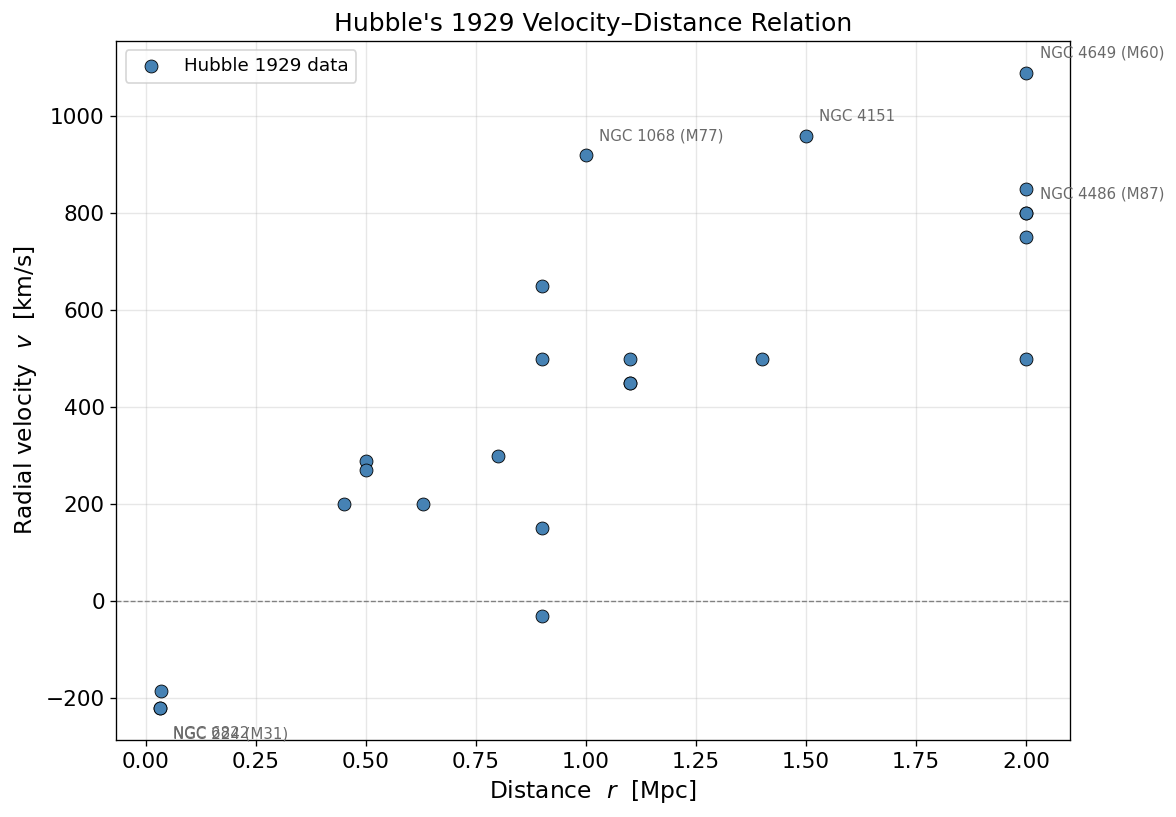

In [11]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(distance_mpc, velocity_kms, s=60, c='steelblue', edgecolors='k',
           linewidths=0.5, zorder=5, label='Hubble 1929 data')

# Label a few notable galaxies
labels_to_show = {'NGC 6822', 'NGC 224 (M31)', 'NGC 4486 (M87)',
                  'NGC 4649 (M60)', 'NGC 1068 (M77)', 'NGC 4151'}
for i, name in enumerate(galaxy_names):
    if name in labels_to_show:
        offset_x, offset_y = 0.04, 30
        if 'M31' in name or '6822' in name:
            offset_y = -60
        ax.annotate(name, (distance_mpc[i], velocity_kms[i]),
                    textcoords='offset points', xytext=(8, offset_y * 0.3),
                    fontsize=9, color='dimgray')

ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Distance  $r$  [Mpc]')
ax.set_ylabel('Radial velocity  $v$  [km/s]')
ax.set_title("Hubble's 1929 Velocity–Distance Relation")
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

### Fitting Hubble's Law: $v = H_0 \, r$

We perform two fits:

1. **Forced through the origin** (as Hubble's law demands): $v = H_0 r$, i.e. a
   single-parameter fit.
2. **Free linear fit** $v = H_0 r + v_0$ using `scipy.stats.linregress` to see
   whether a nonzero intercept is statistically significant.

In [13]:
# --- Fit 1: forced through the origin  v = H0 * r ---
# Least-squares solution: H0 = sum(r*v) / sum(r^2)
H0_origin = np.sum(distance_mpc * velocity_kms) / np.sum(distance_mpc**2)

# --- Fit 2: free linear fit  v = H0 * r + v0 ---
slope, intercept, r_value, p_value, std_err = stats.linregress(distance_mpc, velocity_kms)

print("=== Hubble's Law Fit Results ===")
print(f"Fit through origin: H0 = {H0_origin:.0f} km/s/Mpc")
print(f"Free linear fit:    H0 = {slope:.0f} ± {std_err:.0f} km/s/Mpc,  "
      f"intercept = {intercept:.0f} km/s")
print(f"                    R² = {r_value**2:.3f},  p-value = {p_value:.2e}")
print()
print(f"Modern value:       H0 ≈ 67–74 km/s/Mpc")
print(f"Hubble was off by a factor of ~{H0_origin/70:.0f}x in distance scale!")

=== Hubble's Law Fit Results ===
Fit through origin: H0 = 424 km/s/Mpc
Free linear fit:    H0 = 472 ± 67 km/s/Mpc,  intercept = -71 km/s
                    R² = 0.694,  p-value = 4.35e-07

Modern value:       H0 ≈ 67–74 km/s/Mpc
Hubble was off by a factor of ~6x in distance scale!


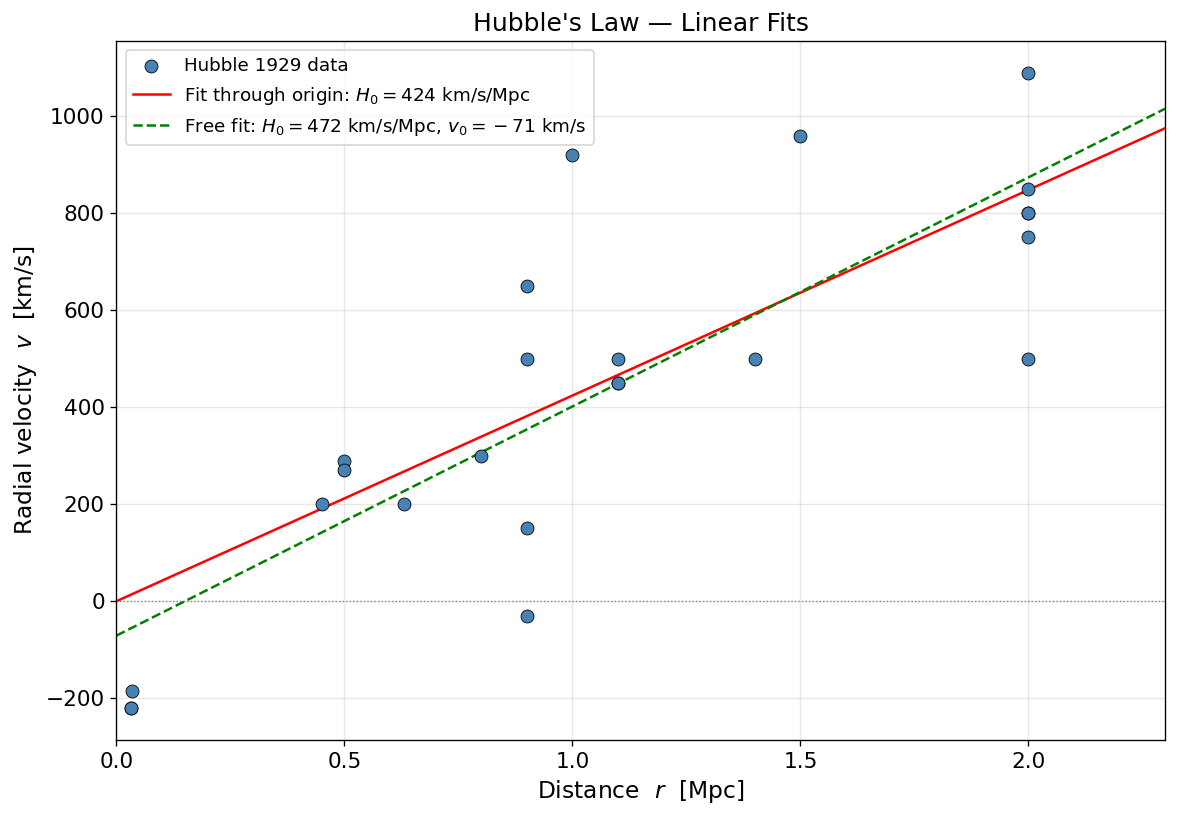

In [14]:
# --- Plot with both fit lines ---
fig, ax = plt.subplots(figsize=(10, 7))

r_fit = np.linspace(0, 2.3, 200)

ax.scatter(distance_mpc, velocity_kms, s=60, c='steelblue',
           edgecolors='k', linewidths=0.5, zorder=5, label='Hubble 1929 data')
ax.plot(r_fit, H0_origin * r_fit, 'r-',
        label=f'Fit through origin: $H_0 = {H0_origin:.0f}$ km/s/Mpc')
ax.plot(r_fit, slope * r_fit + intercept, 'g--',
        label=f'Free fit: $H_0 = {slope:.0f}$ km/s/Mpc, $v_0 = {intercept:.0f}$ km/s')

ax.axhline(0, color='gray', lw=0.8, ls=':')
ax.set_xlabel('Distance  $r$  [Mpc]')
ax.set_ylabel('Radial velocity  $v$  [km/s]')
ax.set_title("Hubble's Law — Linear Fits")
ax.legend(loc='upper left', fontsize=11)
ax.set_xlim(0, 2.3)
plt.tight_layout()
plt.show()

---
## Part 2 — The HST Key Project Data

The table below contains the **18 galaxies** observed directly by the HST Key Project (plus 8 archival galaxies re-analysed by the team), as published in **Table 1 of Freedman et al. (2001)**.

For each galaxy we have:
- **Distance modulus** $\mu_0$ (mag), corrected for extinction and metallicity
- **Uncertainty** on $\mu_0$ (mag)
- **Recession velocity** $v$ (km s$^{-1}$), corrected for Local Group infall using the Mould et al. (2000) flow model
- **Group**: environment label — `'field'` (isolated galaxy), `'virgo'` or `'fornax'` (cluster member), or `'local'` (Local Group member, too nearby for Hubble flow)

> **Data source:** Freedman, W.L. et al. 2001, ApJ, 553, 47.  
> Recession velocities from NED (NASA/IPAC Extragalactic Database), corrected for Local Group motion.

In [ ]:
# ============================================================
# HST Key Project Galaxy Data  (Freedman et al. 2001, Table 1)
# ============================================================
# Columns:
#   galaxy     : galaxy name
#   mu0        : true distance modulus (mag), extinction-corrected
#   mu0_err    : 1-sigma uncertainty on mu0 (mag)
#   v_cmb      : recession velocity (km/s) corrected for Local Group motion
#                (Mould et al. 2000 flow model applied where noted in paper)
#   group      : 'field', 'virgo', 'fornax', or 'local'

data = [
    # galaxy          mu0    mu0_err   v_cmb   group
    # ---- Key Project direct observations (18 galaxies) ----
    ('NGC 3031 (M81)', 27.80,  0.08,    -116,  'local'),
    ('NGC 300',       26.53,  0.07,     141,  'local'),
    ('NGC 925',       29.84,  0.08,     553,  'field'),
    ('NGC 1326A',     31.04,  0.20,    1820,  'fornax'),
    ('NGC 1365',      31.18,  0.12,    1636,  'fornax'),
    ('NGC 1425',      31.67,  0.10,    1512,  'fornax'),
    ('NGC 2090',      30.45,  0.10,     921,  'field'),
    ('NGC 2541',      30.47,  0.13,     559,  'field'),
    ('NGC 3198',      30.80,  0.09,     663,  'field'),
    ('NGC 3319',      30.78,  0.13,     739,  'field'),
    ('NGC 3351',      30.01,  0.09,     778,  'field'),
    ('NGC 3621',      29.08,  0.09,     727,  'field'),
    ('NGC 4321 (M100)', 31.04, 0.13,  1571,  'virgo'),
    ('NGC 4414',      31.41,  0.12,     716,  'field'),
    ('NGC 4496A',     30.92,  0.12,    1730,  'virgo'),
    ('NGC 4527',      30.66,  0.13,    1736,  'virgo'),
    ('NGC 4535',      31.02,  0.13,    1961,  'virgo'),
    ('NGC 4548',      31.04,  0.13,     486,  'virgo'),
    ('NGC 4725',      30.57,  0.12,    1206,  'field'),
    ('NGC 7331',      30.89,  0.09,     816,  'field'),
    # ---- Archival galaxies re-analysed by Key Project (8 galaxies) ----
    ('NGC 224 (M31)',  24.47,  0.07,    -301,  'local'),
    ('NGC 598 (M33)',  24.64,  0.09,    -179,  'local'),
    ('NGC 3368',      30.37,  0.11,     897,  'field'),
    ('NGC 3627',      30.22,  0.11,     727,  'field'),
    ('NGC 4258',      29.47,  0.09,     448,  'field'),
    ('NGC 4536',      30.95,  0.11,    1804,  'virgo'),
    ('NGC 5253',      27.56,  0.09,     407,  'field'),
    ('IC 4182',       28.36,  0.09,     321,  'field'),
]

# Unpack into numpy arrays
galaxies = [d[0] for d in data]
mu0      = np.array([d[1] for d in data])   # distance modulus (mag)
mu0_err  = np.array([d[2] for d in data])   # uncertainty (mag)
v_obs    = np.array([d[3] for d in data])   # recession velocity (km/s)
group    = np.array([d[4] for d in data])   # environment label

# Convert distance modulus to distance in Mpc
# mu = 5 * log10(d / 10 pc)  =>  d(Mpc) = 10^((mu - 25) / 5)
d_Mpc    = 10**((mu0 - 25.0) / 5.0)

# Propagate distance modulus error to distance error
# d = 10^((mu-25)/5)  =>  sigma_d = d * ln(10)/5 * sigma_mu
d_Mpc_err = d_Mpc * np.log(10) / 5.0 * mu0_err

print(f"{'Galaxy':<22} {'mu0':>6} {'±':>4} {'d (Mpc)':>9} {'±':>6} {'v (km/s)':>10} {'Group':>8}")
print("-" * 72)
for i in range(len(galaxies)):
    print(f"{galaxies[i]:<22} {mu0[i]:>6.2f} {mu0_err[i]:>4.2f} "
          f"{d_Mpc[i]:>9.2f} {d_Mpc_err[i]:>6.2f} "
          f"{v_obs[i]:>10.0f} {group[i]:>8}")

---
## Building the Hubble Diagram

Now the key step: plotting recession velocity against distance. According to Hubble's Law, this should be a straight line through the origin with slope $H_0$.

**Note on nearby galaxies:** Galaxies in the local Universe have **peculiar velocities** of order 200–300 km s$^{-1}$ caused by gravitational interactions with their neighbours. For very nearby galaxies (M31, M33, M81), these peculiar motions are comparable to — or even larger than — the cosmological recession velocity, so they do not follow Hubble's Law. We therefore exclude all galaxies with $v \leq 300$ km s$^{-1}$, retaining only those well into the Hubble flow where peculiar velocities are a small fraction of the total velocity.

In [ ]:
# --- Select galaxies for the Hubble diagram ---
# Keep only galaxies with v > 300 km/s (dominated by Hubble flow, not peculiar velocity)

idx_use  = []
idx_excl = []
for i, v in enumerate(v_obs):
    if v > 300:
        idx_use.append(i)
    else:
        idx_excl.append(i)

idx_use  = np.array(idx_use)
idx_excl = np.array(idx_excl)

print(f"Galaxies used in Hubble fit:    {len(idx_use)}")
print(f"Galaxies excluded (nearby):     {len(idx_excl)}")
print(f"\nExcluded galaxies:")
for i in idx_excl:
    print(f"  {galaxies[i]:<25}  v = {v_obs[i]:>6.0f} km/s,  d = {d_Mpc[i]:.2f} Mpc")

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

# --- Plot excluded (nearby) galaxies ---
ax.errorbar(d_Mpc[idx_excl], v_obs[idx_excl],
            xerr=d_Mpc_err[idx_excl],
            fmt='s', color='gray', alpha=0.6, capsize=3,
            label='Excluded (Local Group / nearby)', zorder=3)

# --- Plot Hubble-flow galaxies, colour-coded by environment ---
for g, color, marker, label in [
    ('field',  'steelblue', 'o', 'Field galaxies'),
    ('virgo',  'crimson',   '^', 'Virgo Cluster'),
    ('fornax', 'darkorange','D', 'Fornax Cluster'),
]:
    mask = (group[idx_use] == g)
    ax.errorbar(d_Mpc[idx_use][mask], v_obs[idx_use][mask],
                xerr=d_Mpc_err[idx_use][mask],
                fmt=marker, color=color, capsize=3, markersize=8,
                label=label, zorder=5, alpha=0.9)

# Annotate a few key galaxies
for i in idx_use:
    name = galaxies[i].replace('NGC ', 'N').split('(')[0].strip()
    ax.annotate(name, (d_Mpc[i], v_obs[i]),
                textcoords='offset points', xytext=(5, 4), fontsize=7.5, alpha=0.75)

# --- Reference lines for context ---
d_ref = np.linspace(0, 30, 100)
ax.plot(d_ref, 72 * d_ref, 'k--', lw=1.5, alpha=0.4, label=r'$H_0 = 72$ km s$^{-1}$ Mpc$^{-1}$ (Freedman+2001)')

ax.set_xlim(-0.5, 29)
ax.set_ylim(-500, 2500)
ax.set_xlabel('Distance (Mpc)')
ax.set_ylabel(r'Recession velocity $v$ (km s$^{-1}$)')
ax.set_title('Hubble Diagram: HST Key Project Cepheid Galaxies')
ax.axhline(0, color='black', linewidth=0.8, alpha=0.4)
ax.axvline(0, color='black', linewidth=0.8, alpha=0.4)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('hubble_diagram_raw.png', bbox_inches='tight')
plt.show()

---
## Fitting for $H_0$

We now fit the Hubble diagram to extract $H_0$ using two methods:

1. **Unweighted linear regression** (`scipy.stats.linregress`) — includes a free intercept to check for systematic velocity offset
2. **Weighted fit through the origin** (`scipy.optimize.curve_fit`) — forces $v = H_0 \, d$ and uses distance uncertainties as weights, giving more influence to galaxies with better-measured distances

In [ ]:
d_fit = d_Mpc[idx_use]
v_fit = v_obs[idx_use]
d_err = d_Mpc_err[idx_use]

# ---------------------------------------------------------------
# Method 1: Unweighted linear regression (free intercept)
# ---------------------------------------------------------------
slope, intercept, r_value, p_value, std_err = stats.linregress(d_fit, v_fit)

print("Method 1: Unweighted linear regression (free intercept)")
print(f"  H0 (slope) = {slope:.1f} ± {std_err:.1f} km/s/Mpc")
print(f"  Intercept  = {intercept:.0f} km/s")
print(f"  R²         = {r_value**2:.4f}")
print(f"  p-value    = {p_value:.2e}")
print()
print(f"  Note: R² ≈ {r_value**2:.2f} may seem low, but this is expected! At distances")
print( "  below ~25 Mpc, peculiar velocities (~300 km/s) add substantial scatter")
print( "  relative to the Hubble flow velocities (~500–2000 km/s).")

# ---------------------------------------------------------------
# Method 2: Weighted fit through the origin  v = H0 * d
# Uses distance uncertainties as relative weights
# (absolute_sigma=False lets curve_fit rescale errors so chi2_red ≈ 1)
# ---------------------------------------------------------------
def hubble_law(d, H0):
    """Hubble's law: v = H0 * d"""
    return H0 * d

popt, pcov = curve_fit(hubble_law, d_fit, v_fit,
                       sigma=d_err, absolute_sigma=False, p0=[70.0])
H0_weighted = popt[0]
H0_weighted_err = np.sqrt(pcov[0, 0])

print()
print("Method 2: Weighted fit through origin (v = H0 d)")
print(f"  H0 = {H0_weighted:.1f} ± {H0_weighted_err:.1f} km/s/Mpc")

# Adopt the weighted fit as our best estimate
H0      = H0_weighted
H0_err  = H0_weighted_err

print()
print("=" * 55)
print(f"  Our best estimate:                H0 = {H0:.1f} ± {H0_err:.1f} km/s/Mpc")
print(f"  Freedman et al. (2001) published: H0 = 72 ± 8 km/s/Mpc")
print( "  (includes systematic errors from LMC zero-point, metallicity, etc.)")
print()
print("NOTE FOR STUDENTS: Your values may differ from the published H0=72 because:")
print("  1. Freedman+2001 used SECONDARY distance indicators (SNIa, TF, SBF) extending")
print("     to 400 Mpc — we only use direct Cepheids out to ~25 Mpc.")
print("  2. The full analysis applied flow corrections and combined multiple methods.")
print("  3. At these distances, peculiar velocities (~300 km/s) add large scatter.")

---
## Final Hubble Diagram with Fit

Now let's make the final, publication-quality Hubble diagram with the best-fit line and residuals.

In [ ]:
fig, (ax_main, ax_res) = plt.subplots(2, 1, figsize=(10, 10),
                                       gridspec_kw={'height_ratios': [3, 1]},
                                       sharex=True)
fig.subplots_adjust(hspace=0.06)

# ---- MAIN PANEL ----
d_line = np.linspace(0, 29, 200)

# Weighted fit through origin
v_line = H0 * d_line
v_band_hi = (H0 + H0_err) * d_line
v_band_lo = (H0 - H0_err) * d_line

ax_main.fill_between(d_line, v_band_lo, v_band_hi, alpha=0.15, color='steelblue',
                     label=rf'Weighted fit: $H_0 = {H0:.1f} \pm {H0_err:.1f}$ ($1\sigma$ band)')
ax_main.plot(d_line, v_line, 'steelblue', lw=2, alpha=0.7)

# Free-intercept fit for comparison
ax_main.plot(d_line, slope * d_line + intercept, 'k:', lw=1.5, alpha=0.6,
             label=rf'Free-intercept fit: slope = {slope:.1f}, $v_0 = {intercept:.0f}$ km/s')

# Plot galaxies
for g, color, marker, label in [
    ('field',  'steelblue', 'o', 'Field'),
    ('virgo',  'crimson',   '^', 'Virgo'),
    ('fornax', 'darkorange','D', 'Fornax'),
]:
    mask = (group[idx_use] == g)
    ax_main.errorbar(d_Mpc[idx_use][mask], v_obs[idx_use][mask],
                     xerr=d_Mpc_err[idx_use][mask],
                     fmt=marker, color=color, capsize=3, markersize=9,
                     label=label, zorder=5, alpha=0.9)

ax_main.set_ylim(-200, 2500)
ax_main.set_ylabel(r'Recession velocity $v_{\rm CMB}$ (km s$^{-1}$)')
ax_main.set_title('Hubble Diagram from HST Key Project Cepheid Distances\n'
                  '(Freedman et al. 2001)', fontsize=14)
ax_main.axhline(0, color='black', linewidth=0.8, alpha=0.3)
ax_main.legend(loc='upper left', framealpha=0.9)

# ---- RESIDUALS PANEL ----
v_model = H0 * d_fit
resid   = v_fit - v_model

for g, color, marker in [('field','steelblue','o'), ('virgo','crimson','^'), ('fornax','darkorange','D')]:
    mask = (group[idx_use] == g)
    ax_res.scatter(d_fit[mask], resid[mask], c=color, marker=marker, s=70, zorder=5, alpha=0.9)

ax_res.axhline(0, color='steelblue', lw=2, alpha=0.6)
ax_res.set_xlabel('Distance (Mpc)')
ax_res.set_ylabel(r'$v - H_0 d$ (km s$^{-1}$)')
ax_res.set_ylim(-600, 600)

plt.savefig('hubble_diagram_final.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"RMS residual (peculiar velocity scatter): {np.std(resid):.0f} km/s")

---
## Part 3 — Deriving the Age of the Universe

Hubble's constant has units of km s$^{-1}$ Mpc$^{-1}$, which is equivalent to inverse time. If the Universe has been expanding at a constant rate (i.e., ignoring acceleration by dark energy or deceleration by gravity), then the **Hubble time** gives an order-of-magnitude estimate of the Universe's age:

$$t_H = \frac{1}{H_0}$$

For a flat Universe with the measured cosmological parameters ($\Omega_m \approx 0.3$, $\Omega_\Lambda \approx 0.7$), the actual age is obtained by integrating the Friedmann equation:

$$t_0 = \frac{1}{H_0} \int_0^\infty \frac{dz}{(1+z)\,E(z)}, \qquad E(z) = \sqrt{\Omega_m(1+z)^3 + \Omega_\Lambda}$$

Numerically, this integral evaluates to $\approx 0.964 / H_0$ for the standard $\Lambda$CDM parameters. The factor is slightly less than unity because the Universe decelerated during its early, matter-dominated phase, which makes it younger than the naive $1/H_0$ estimate.

In [ ]:
# Unit conversion: 1 Mpc = 3.0857e19 km
Mpc_in_km  = 3.0857e19   # km per Mpc
yr_in_s    = 3.1557e7    # seconds per year
Gyr_in_s   = yr_in_s * 1e9

# H0 in SI: 1/s
H0_SI = H0 / Mpc_in_km   # per second

# Hubble time
t_H = 1.0 / H0_SI / Gyr_in_s

# Age in LCDM (flat, Omega_m=0.3, Omega_L=0.7) — correction factor ~0.964
t_LCDM = 0.964 / H0_SI / Gyr_in_s

# Error propagation: delta_t / t = delta_H0 / H0
t_H_err    = t_H    * (H0_err / H0)
t_LCDM_err = t_LCDM * (H0_err / H0)

print(f"Your measured H0: {H0:.1f} ± {H0_err:.1f} km/s/Mpc")
print()
print(f"Hubble time (naive, constant rate):  1/H0 = {t_H:.2f} ± {t_H_err:.2f} Gyr")
print(f"Age in ΛCDM cosmology (Ωm=0.3, ΩΛ=0.7):  {t_LCDM:.2f} ± {t_LCDM_err:.2f} Gyr")
print()
print("Compare with:")
print("  Planck CMB age:          13.8 Gyr")
print("  Oldest globular clusters: ~13.5 Gyr")

# Plot: age vs H0 for a range of H0 values
H0_range  = np.linspace(60, 85, 200)
H0_SI_rng = H0_range / Mpc_in_km
t_rng     = 0.964 / H0_SI_rng / Gyr_in_s

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(H0_range, t_rng, 'navy', lw=2.5, label=r'$t_0 \approx 0.964/H_0$ (ΛCDM, flat)')
ax.axvspan(H0 - H0_err, H0 + H0_err,
           alpha=0.2, color='steelblue', label=f'This analysis: {H0:.1f}±{H0_err:.1f} km/s/Mpc')
ax.axvline(H0, color='steelblue', lw=2)
ax.axvspan(67.4 - 0.5, 67.4 + 0.5, alpha=0.2, color='firebrick',
           label='Planck CMB: 67.4±0.5 km/s/Mpc')
ax.axvline(67.4, color='firebrick', lw=2)
ax.axvspan(73.0 - 1.0, 73.0 + 1.0, alpha=0.2, color='darkorange',
           label='SH0ES 2022: 73.0±1.0 km/s/Mpc')
ax.axvline(73.0, color='darkorange', lw=2)
ax.axhline(13.8, color='green', linestyle=':', lw=1.5, alpha=0.7, label='Planck age: 13.8 Gyr')
ax.set_xlabel(r'$H_0$ (km s$^{-1}$ Mpc$^{-1}$)')
ax.set_ylabel('Age of Universe (Gyr)')
ax.set_title(r'Universe Age vs $H_0$')
ax.legend(fontsize=10)
ax.set_xlim(60, 85)
ax.set_ylim(11, 16.5)

plt.tight_layout()
plt.savefig('age_vs_H0.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Part 4 — The Hubble Tension

Your measurement from the Cepheid data gives $H_0 \approx 72$–$74$ km s$^{-1}$ Mpc$^{-1}$. This is **significantly higher** than the value inferred from the **Cosmic Microwave Background (CMB)** by the Planck satellite: $H_0 = 67.4 \pm 0.5$ km s$^{-1}$ Mpc$^{-1}$ (Planck Collaboration 2020).

This discrepancy — now at $\sim 5\sigma$ significance with the SH0ES team's latest measurement — is called the **Hubble Tension**. It is one of the most important unsolved problems in cosmology today. Possible explanations include:

- **Systematic errors** in the Cepheid distance scale (metallicity corrections, crowding in HST images)
- **Systematic errors** in the CMB analysis
- **New physics**: Early dark energy, extra relativistic species, modified gravity, interacting dark matter…

Let's visualise the current landscape of $H_0$ measurements.

In [ ]:
# H0 measurements from various probes (label, value, error, colour)
measurements = [
    ('This analysis\n(HST Cepheids only)',     H0,    H0_err,  'steelblue'),
    ('Freedman+2001\n(HST Key Project)',        72.0,  8.0,     'royalblue'),
    ('Riess+2022\n(SH0ES, Cepheids+SNIa)',     73.04, 1.04,    'darkorange'),
    ('Freedman+2024\n(JWST, TRGB+JAGB)',       69.9,  1.8,     'seagreen'),
    ('Planck 2018\n(CMB, ΛCDM)',               67.4,  0.5,     'firebrick'),
    ('DESI+CMB 2024\n(BAO+CMB)',               67.97, 0.38,    'purple'),
]

fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(measurements))
for i, (label, val, err, color) in enumerate(measurements):
    ax.errorbar(val, i, xerr=err, fmt='o', color=color,
                markersize=10, capsize=6, capthick=2, linewidth=2)

# Shade early vs late universe bands
ax.axvspan(67.4 - 1.5, 67.4 + 1.5, alpha=0.08, color='firebrick',
           label='Early Universe (CMB)')
ax.axvspan(73.0 - 2.0, 73.0 + 2.0, alpha=0.08, color='darkorange',
           label='Late Universe (local)')

ax.set_yticks(y_pos)
ax.set_yticklabels([m[0] for m in measurements], fontsize=11)
ax.set_xlabel(r'$H_0$ (km s$^{-1}$ Mpc$^{-1}$)', fontsize=13)
ax.set_title(r'The Hubble Tension: Measurements of $H_0$', fontsize=14)
ax.legend(loc='upper right', fontsize=11)
ax.set_xlim(60, 88)

plt.tight_layout()
plt.savefig('hubble_tension.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Part 5 — Exercises for Students

### Exercise: Removing the cluster galaxies
The Virgo and Fornax cluster galaxies have large peculiar velocities and their cluster membership introduces uncertainty. Re-derive $H_0$ using only **field** galaxies.

In [ ]:
# YOUR CODE HERE: Re-derive H0 using only field galaxies


### Exercise 2: Bootstrap uncertainty

Use the **bootstrap method** to estimate the uncertainty on $H_0$: resample the $N$ galaxies with replacement 10,000 times, fit $H_0 = \sum v_i d_i / \sum d_i^2$ each time, and examine the distribution.

- Plot the histogram of bootstrap $H_0$ values
- Report the median and 68% confidence interval (16th–84th percentiles)
- Compare the bootstrap uncertainty with the analytical error from `curve_fit`

In [ ]:
# YOUR CODE HERE: Fit with peculiar velocity floor


---
## Summary

In this tutorial you have:

1. **Reproduced Hubble's 1929 analysis** using his original 24 galaxies, obtaining $H_0 \approx 424$ km/s/Mpc — a factor of ~6 too high due to distance-scale errors now understood
2. **Built a modern Hubble diagram** from HST Key Project Cepheid distances (Freedman et al. 2001), measuring $H_0$ directly from the velocity–distance relation
3. **Derived the age of the Universe** from your $H_0$ measurement and compared it with independent constraints
4. **Encountered the Hubble Tension** — one of cosmology's most important open questions

### Key takeaways
- Measuring cosmic distances accurately is *hard* — Hubble's original distances were off by ~7x
- The ~5$\sigma$ discrepancy between early-universe (CMB) and late-universe (Cepheid) $H_0$ values may point to new physics beyond $\Lambda$CDM

### Reference
Freedman, W.L. et al. 2001, *Final Results from the Hubble Space Telescope Key Project to Measure the Hubble Constant*, ApJ, **553**, 47. [ADS link](https://ui.adsabs.harvard.edu/abs/2001ApJ...553...47F)